# MS MARCO Training Data and Hard-Negative Analysis

In [105]:
from __future__ import annotations

import random
import statistics
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from tokenizers import Tokenizer

# Detect repo root whether notebook was opened from repo root or notebooks/
cwd = Path.cwd()

if (cwd / "src").exists():
    repo_root = cwd
elif (cwd.parent / "src").exists():
    repo_root = cwd.parent
else:
    raise RuntimeError(f"Could not find src/ from current directory: {cwd}")

src_path = repo_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Repo root: {repo_root}")
print(f"Added to sys.path: {src_path}")

from neural_search.data import MSMARCOPairsDataset

Repo root: c:\Users\Myvari\Desktop\Neural-Search-Engine
Added to sys.path: c:\Users\Myvari\Desktop\Neural-Search-Engine\src


In [ ]:
MAX_EXAMPLES = 5_000
QUERY_MAX_LENGTH = 64
PASSAGE_MAX_LENGTH = 256
TOKENIZER_PATH = repo_root / "data/tokenizer.json"
SEED = 42

In [107]:
dataset = MSMARCOPairsDataset(
    split="train",
    max_examples=MAX_EXAMPLES,
    shuffle=True,
    seed=SEED,
)

len(dataset)

5000

## Inspect examples

In [108]:
examples = [dataset[i] for i in range(len(dataset))]

df = pd.DataFrame(examples)
df.head()

,query,positive_passage
0,what makes a sore throat sore,Infections from viruses or bacteria are the ma...
1,carrie underwood net worth,Carrie Underwood Net Worth: Carrie Underwood i...
2,do tulips and daffodils grow year after year,"Shop for Tulip Bulbs. As many gardeners know, ..."
3,originally african slaves were brought to the ...,"Originally, African slaves were brought to the..."
4,what causes achondroplasia,Achondroplasia is a bone growth disorder that ...


In [109]:
sample_df = df.sample(n=20, random_state=SEED)

for i, row in enumerate(sample_df.itertuples(index=False), start=1):
    print(f"\n[{i}]")
    print("QUERY:")
    print(row.query)
    print("\nPOSITIVE PASSAGE:")
    print(row.positive_passage[:700])
    print("-" * 100)


[1]
QUERY:
viral condition definition

POSITIVE PASSAGE:
Viral infection: Infection caused by the presence of a virus in the body. Depending on the virus and the person's state of health, various viruses can infect almost any type of body tissue, from the brain to the skin.
----------------------------------------------------------------------------------------------------

[2]
QUERY:
who signs a lease owner or property manager

POSITIVE PASSAGE:
Related Ads. Typically, it’s the landlord or property owner who signs a lease or rental agreement with tenants. For small rental properties, the owner and manager may be the same person.
----------------------------------------------------------------------------------------------------

[3]
QUERY:
what is scars

POSITIVE PASSAGE:
A scar is the body's natural way of healing and replacing lost or damaged skin. A scar is usually composed of fibrous tissue. Scars may be formed for many different reasons, including as a result of infections, surg

Manually inspected 20 random query-positive pairs. Most positives directly answered the query, some were only partially relevant, which is not unexpected.

## Analyze lengths

In [110]:
df["query_word_len"] = df["query"].str.split().apply(len)
df["passage_word_len"] = df["positive_passage"].str.split().apply(len)

df[["query_word_len", "passage_word_len"]].describe()

,query_word_len,passage_word_len
count,5000.000000,5000.000000
mean,6.043200,72.770000
std,2.337183,26.501139
min,2.000000,10.000000
25%,4.000000,50.000000
50%,6.000000,73.000000
75%,7.000000,93.000000
max,17.000000,185.000000


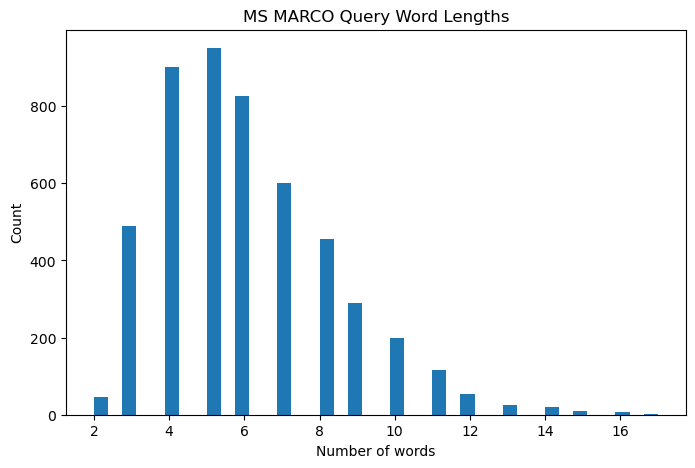

In [111]:
plt.figure(figsize=(8, 5))
plt.hist(df["query_word_len"], bins=40)
plt.title("MS MARCO Query Word Lengths")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.show()

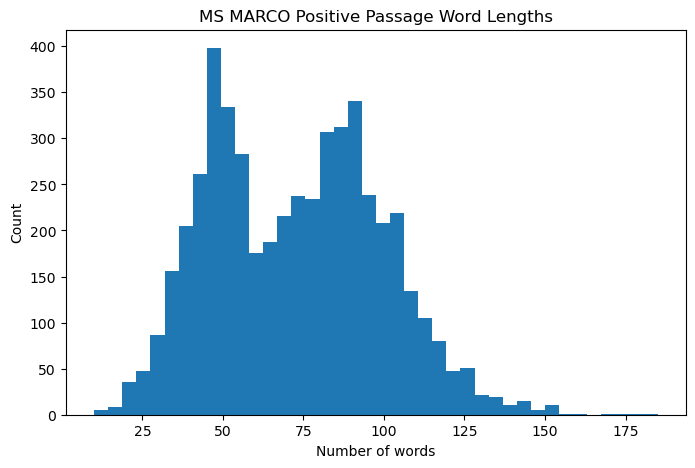

In [112]:
plt.figure(figsize=(8, 5))
plt.hist(df["passage_word_len"], bins=40)
plt.title("MS MARCO Positive Passage Word Lengths")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.show()

In [113]:
tokenizer = Tokenizer.from_file(TOKENIZER_PATH)

tokenizer.get_vocab_size()

30000

In [114]:
def token_len(text: str) -> int:
    return len(tokenizer.encode(text).ids)

df["query_token_len"] = df["query"].apply(token_len)
df["passage_token_len"] = df["positive_passage"].apply(token_len)

df[["query_token_len", "passage_token_len"]].describe()

,query_token_len,passage_token_len
count,5000.000000,5000.000000
mean,8.877600,96.490600
std,2.471162,34.414404
min,4.000000,19.000000
25%,7.000000,67.000000
50%,8.000000,97.000000
75%,10.000000,122.000000
max,26.000000,221.000000


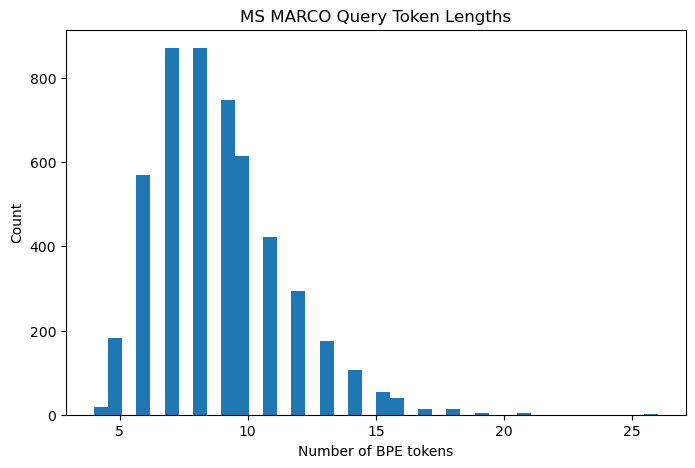

In [115]:
plt.figure(figsize=(8, 5))
plt.hist(df["query_token_len"], bins=40)
plt.title("MS MARCO Query Token Lengths")
plt.xlabel("Number of BPE tokens")
plt.ylabel("Count")
plt.show()

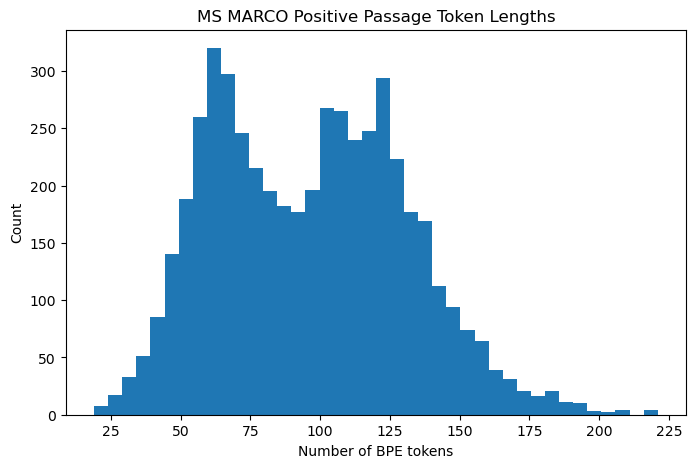

In [116]:
plt.figure(figsize=(8, 5))
plt.hist(df["passage_token_len"], bins=40)
plt.title("MS MARCO Positive Passage Token Lengths")
plt.xlabel("Number of BPE tokens")
plt.ylabel("Count")
plt.show()

## Analyze truncation and suspicious examples

In [117]:
query_truncation_rate = (df["query_token_len"] > QUERY_MAX_LENGTH).mean()
passage_truncation_rate = (df["passage_token_len"] > PASSAGE_MAX_LENGTH).mean()

print(f"Query max length: {QUERY_MAX_LENGTH}")
print(f"Queries truncated: {query_truncation_rate:.2%}")

print(f"\nPassage max length: {PASSAGE_MAX_LENGTH}")
print(f"Passages truncated: {passage_truncation_rate:.2%}")

Query max length: 64
Queries truncated: 0.00%

Passage max length: 256
Passages truncated: 0.00%


query and passage lengths are generally well within the max lengths, acceptable.

In [118]:
df.sort_values("query_token_len", ascending=False)[["query", "query_token_len"]].head(10)

,query,query_token_len
1473,The difference between “tasters” and “non-tast...,26
1349,how long does it usually take to get a disabil...,21
823,Which Constitutional Amendment set up the curr...,21
4338,what is the fourth-largest island in the world...,21
4339,what is the fourth-largest island in the world...,21
3375,what are two blood vessels enter/leave at the ...,21
3679,how long does it take a first class letter to ...,19
3680,how long does it take a first class letter to ...,19
3501,the liability of a stockholder is usually limi...,19
2070,what does the king tell rosencrantz and guilde...,19


In [119]:
df.sort_values("passage_token_len", ascending=False)[["positive_passage", "passage_token_len"]].head(10)

,positive_passage,passage_token_len
493,If you have transmitted your return by NETFILE...,221
2474,HALAVEN (eribulin mesylate) Injection is a non...,221
4780,"If you live in your property year-round, then ...",216
3455,Protactinium (atomic number 91) is a metal dis...,216
683,Subject to credit approval & may require a dep...,210
3631,"First, let's review the definition of an iamb....",210
2082,Cheshire (/ˈtʃɛʃər/ or /ˈtʃɛʃɪər/ ; archaicall...,207
4307,Saltpeter is a common food preservative and ad...,207
4172,"[ syll. sa-yyi-da, say-y- ida ] The baby girl ...",204
4342,"A ton of refrigeration (12,000 BTUs per ton) i...",202


In [120]:
df[df["passage_word_len"] <= 10].head(20)

,query,positive_passage,query_word_len,passage_word_len,query_token_len,passage_token_len
585,araya name meaning,Meaning: The Arabic name Araya means-a form of...,3,10,6,19


In [121]:
df[df["query_word_len"] <= 2].head(20)

,query,positive_passage,query_word_len,passage_word_len,query_token_len,passage_token_len
156,locally definition,Definition of LOCALLY. 1. : with respect to a ...,2,23,4,34
240,taboola cost,That would translate into revenue per click (u...,2,104,6,145
428,salmonella bacteria,"Salmonella infection, or salmonellosis, is a b...",2,44,4,57
563,invest definition,DEFINITION of 'Investing'. The act of committi...,2,53,4,70
749,define feted,"noun. Fete is defined as an outside festival, ...",2,20,5,30
895,daycare cost,The average cost of center-based daycare in th...,2,90,4,134
927,preening definition,"When a bird is preening, she uses her beak to ...",2,52,5,64
933,define incipient,1 Beginning to happen or develop: he could fee...,2,92,6,129
985,mineral definition,"A mineral is a naturally occurring substance, ...",2,46,4,57
1128,definition Shuff,Top Definition. Shuff. A noun derived from com...,2,53,5,67


## lexical overlap analysis between queries and positive passages

In [122]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import paired_cosine_distances

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=20_000,
)

all_texts = pd.concat([df["query"], df["positive_passage"]], ignore_index=True)
vectorizer.fit(all_texts)

query_tfidf = vectorizer.transform(df["query"])
passage_tfidf = vectorizer.transform(df["positive_passage"])

df["tfidf_pair_similarity"] = 1.0 - paired_cosine_distances(
    query_tfidf,
    passage_tfidf,
)

df["tfidf_pair_similarity"].describe()

count    5.000000e+03
mean     4.013614e-01
std      1.771097e-01
min     -4.440892e-16
25%      2.760275e-01
50%      4.007984e-01
75%      5.219831e-01
max      8.973941e-01
Name: tfidf_pair_similarity, dtype: float64

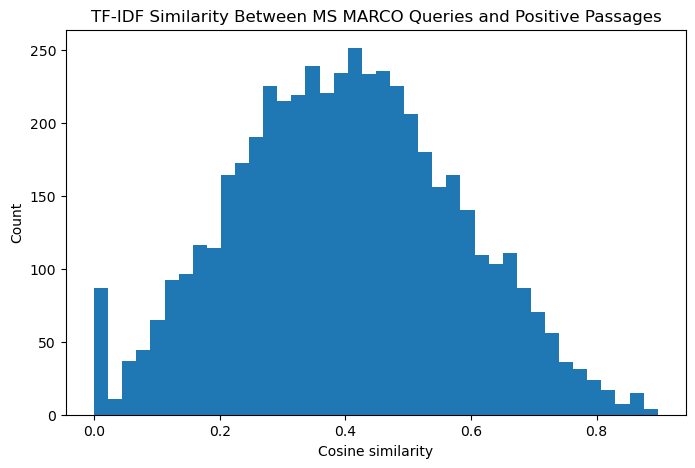

In [123]:
plt.figure(figsize=(8, 5))
plt.hist(df["tfidf_pair_similarity"], bins=40)
plt.title("TF-IDF Similarity Between MS MARCO Queries and Positive Passages")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.show()

In [124]:
low_similarity = df.sort_values("tfidf_pair_similarity").head(10)

for i, row in enumerate(low_similarity.itertuples(index=False), start=1):
    print(f"\n[{i}] similarity={row.tfidf_pair_similarity:.4f}")
    print("QUERY:")
    print(row.query)
    print("\nPOSITIVE PASSAGE:")
    print(row.positive_passage[:700])
    print("-" * 100)


[1] similarity=-0.0000
QUERY:
nephron site of filtrate formation

POSITIVE PASSAGE:
Processes of the Kidneys. Filtration. Filtration is the mass movement of water and solutes from plasma to the renal tubule that occurs in the renal corpuscle. About 20% of the plasma volume passing through the glomerulus at any given time is filtered. This means that about 180 liters of fluid are filtered by the kidneys every day.
----------------------------------------------------------------------------------------------------

[2] similarity=-0.0000
QUERY:
what does lipid mean in biology

POSITIVE PASSAGE:
Definition. noun, plural: lipids. A fatty or waxy organic compound that is readily soluble in nonpolar solvent (e.g. ether) but not in polar solvent (e.g water). Its major biological functions involve energy storage, structural component of cell membrane, and cell signaling. Supplement. Examples of lipids are waxes, oils, sterols, cholesterol, fat-soluble vitamins, monoglycerides, diglycerides, t

In [125]:
high_similarity = df.sort_values("tfidf_pair_similarity", ascending=False).head(10)

for i, row in enumerate(high_similarity.itertuples(index=False), start=1):
    print(f"\n[{i}] similarity={row.tfidf_pair_similarity:.4f}")
    print("QUERY:")
    print(row.query)
    print("\nPOSITIVE PASSAGE:")
    print(row.positive_passage[:700])
    print("-" * 100)


[1] similarity=0.8974
QUERY:
what is a leachate collection system

POSITIVE PASSAGE:
Leachate Collection. Leachate is liquid generated from rainfall and the natural decomposition of waste that is filtered through the landfill to a leachate collection system. The leachate collection system's job is to direct the leachate to collection sumps so it can be properly removed from the landfill. The leachate collection system is designed with a minimum 2 percent slope to drain to collection sumps. A leachate collection sump consists of an HDPE riser and submersible pump. Leachate drains to the leachate collection system, where it is transferred to a central collection pump and piped to an onsite holding tank or it can be re-circulated in the areas underlain by Subtitle D liner syste
----------------------------------------------------------------------------------------------------

[2] similarity=0.8852
QUERY:
is the harpy eagle endangered

POSITIVE PASSAGE:
The Harpy Eagle has found it's wa

TF-IDF similarity was not sufficient to determine pair correctness. Manual inspection showed that some low-similarity pairs were still relevant which suggests that lexical overlap alone is weak for this task and motivates using neural embeddings.

## Example hard negatives

In [ ]:
import json

MINED_NEGATIVES_PATH = repo_root / "data/cache/msmarco_hard_negatives.jsonl"

if not MINED_NEGATIVES_PATH.exists():
    raise FileNotFoundError(
        f"{MINED_NEGATIVES_PATH} does not exist. "
        "Run scripts/mine_hard_negatives.py first."
    )

records = []

with open(MINED_NEGATIVES_PATH, "r", encoding="utf-8") as in_file:
    for line in in_file:
        if line.strip():
            records.append(json.loads(line))

len(records)

5000

In [127]:
mined_df = pd.DataFrame(records)
mined_df.head()

,query,positive_passage,hard_negatives,hard_negative_scores
0,what does epitome mean,Full Definition of EPITOME. 1. a: a summary of...,[The meaning of epitome is an example of the b...,"[20.068809424082776, 15.654818684273504]"
1,bell curve is called,Bell curve may refer to: 1 A Gaussian functio...,[bell curve definition bell curves also called...,"[28.650678339482553, 27.814007215423814]"
2,what are centrioles composed of,In cell biology a centriole (centri- + -ole) i...,[Centrioles are cylindrical structures that ar...,"[22.959994852192843, 21.228026091050815]"
3,is it good to use stay on capsules,Stay-On is enriched with pure and potent herbs...,[The recommended dosage for Stay Erect MSPF is...,"[26.946747596632, 20.835858594372972]"
4,does the gracilis bamboo drop leaves,Spread. 3m. Description: This is the most beau...,[Slender Weavers – gracilis sub species. Clump...,"[30.33488420308807, 29.221035813521908]"


In [128]:
mined_df["num_hard_negatives"] = mined_df["hard_negatives"].apply(len)

mined_df["num_hard_negatives"].describe()

count    5000.0
mean        2.0
std         0.0
min         2.0
25%         2.0
50%         2.0
75%         2.0
max         2.0
Name: num_hard_negatives, dtype: float64

In [129]:
mined_df["num_hard_negatives"].value_counts().sort_index()

num_hard_negatives
2    5000
Name: count, dtype: int64

In [130]:
sample_mined = mined_df.sample(n=10, random_state=SEED)

for i, row in enumerate(sample_mined.itertuples(index=False), start=1):
    print(f"\n[{i}]")
    print("QUERY:")
    print(row.query)

    print("\nPOSITIVE:")
    print(row.positive_passage[:700])

    print("\nHARD NEGATIVES:")
    for j, negative in enumerate(row.hard_negatives, start=1):
        print(f"\n  Negative {j}:")
        print(negative[:700])

    if hasattr(row, "hard_negative_scores"):
        print("\nBM25 scores:")
        print(row.hard_negative_scores)

    print("-" * 120)


[1]
QUERY:
what is lighttpd

POSITIVE:
lighttpd (pronounced lighty) is an open-source web server optimized for speed-critical environments while remaining standards-compliant, secure and flexible. lighttpd supports the FastCGI, SCGI and CGI interfaces to external programs, allowing web applications written in any programming language to be used with the server. As a particularly popular language, PHP performance has received special attention.

HARD NEGATIVES:

  Negative 1:
Note that lighttpd does not support .htaccess files as some web servers do to configure directory specific server settings. Instead, it uses a centrally configured system using lighttpd.conf to define all settings, using powerful matching functions. This still means that you have to manually set up directory settings. Lighttpd. Lighttpd is a highly-configurable, lightweight web server. See lighttpd and http://www.lighttpd.net/ . There are many modules available for lighttpd that can be installed and configured. Fo

In [131]:
def normalize_text_for_check(text: str) -> str:
    return " ".join(str(text).lower().strip().split())


def has_exact_positive_duplicate(row) -> bool:
    positive = normalize_text_for_check(row["positive_passage"])

    return any(
        normalize_text_for_check(negative) == positive
        for negative in row["hard_negatives"]
    )


mined_df["has_exact_positive_duplicate"] = mined_df.apply(
    has_exact_positive_duplicate,
    axis=1,
)

mined_df["has_exact_positive_duplicate"].value_counts()

has_exact_positive_duplicate
False    5000
Name: count, dtype: int64

In [132]:
all_scores = [
    score
    for scores in mined_df["hard_negative_scores"]
    for score in scores
]

pd.Series(all_scores).describe()

count    10000.000000
mean        26.622212
std          8.613907
min          6.161624
25%         20.226212
50%         25.736617
75%         31.562370
max         91.682040
dtype: float64

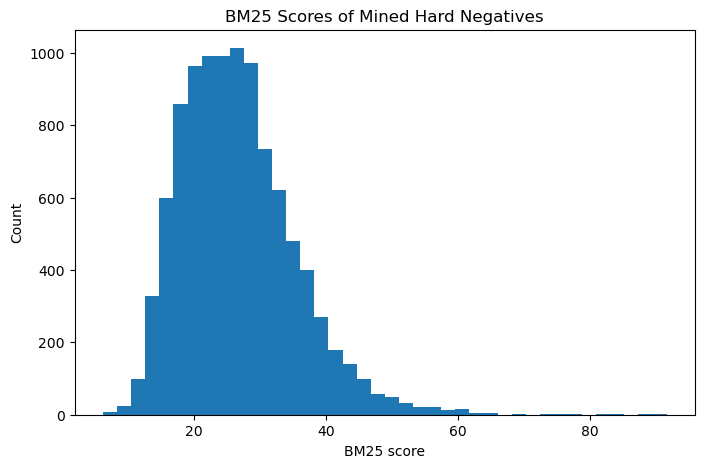

In [133]:
plt.figure(figsize=(8, 5))
plt.hist(all_scores, bins=40)
plt.title("BM25 Scores of Mined Hard Negatives")
plt.xlabel("BM25 score")
plt.ylabel("Count")
plt.show()

In [134]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import paired_cosine_distances

comparison_rows = []

for row in mined_df.itertuples(index=False):
    query = row.query
    positive = row.positive_passage

    comparison_rows.append(
        {
            "query": query,
            "text": positive,
            "kind": "positive",
        }
    )

    for negative in row.hard_negatives:
        comparison_rows.append(
            {
                "query": query,
                "text": negative,
                "kind": "hard_negative",
            }
        )

comparison_df = pd.DataFrame(comparison_rows)

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=20_000,
)

all_texts = pd.concat(
    [comparison_df["query"], comparison_df["text"]],
    ignore_index=True,
)

vectorizer.fit(all_texts)

query_vectors = vectorizer.transform(comparison_df["query"])
text_vectors = vectorizer.transform(comparison_df["text"])

comparison_df["query_text_tfidf_similarity"] = 1.0 - paired_cosine_distances(
    query_vectors,
    text_vectors,
)

comparison_df.groupby("kind")["query_text_tfidf_similarity"].describe()

,count,mean,std,min,25%,50%,75%,max
kind,,,,,,,,
hard_negative,10000.0,0.458315,0.167302,-2.220446e-16,0.344278,0.464551,0.579294,0.938901
positive,5000.0,0.406111,0.180985,-6.661338e-16,0.276441,0.406670,0.539154,0.951485


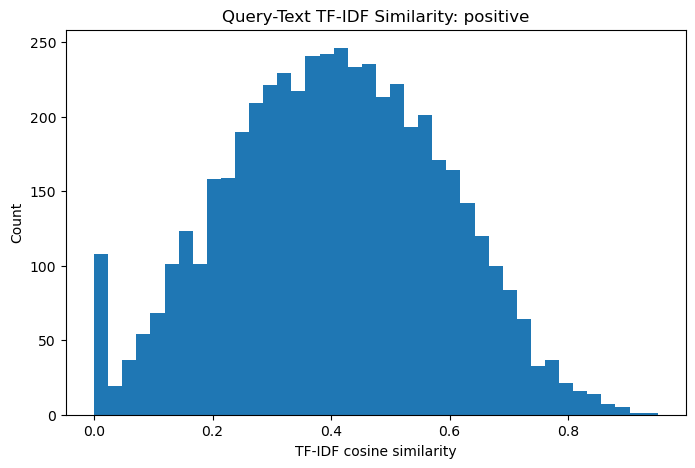

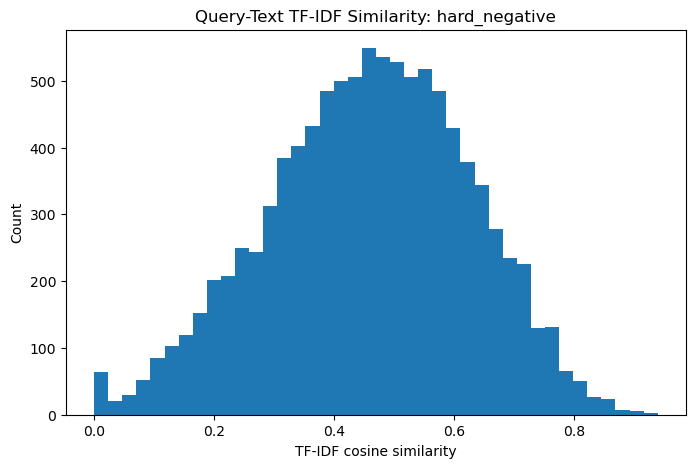

In [135]:
for kind in ["positive", "hard_negative"]:
    subset = comparison_df[comparison_df["kind"] == kind]

    plt.figure(figsize=(8, 5))
    plt.hist(subset["query_text_tfidf_similarity"], bins=40)
    plt.title(f"Query-Text TF-IDF Similarity: {kind}")
    plt.xlabel("TF-IDF cosine similarity")
    plt.ylabel("Count")
    plt.show()

We mined BM25 hard-negative candidates from MS MARCO candidate passages. For each query-positive pair, BM25 retrieved lexically similar passages, and the miner removed exact known positives before keeping the top remaining candidates.

Manual inspection showed that many hard negatives are topically close to the query. Some are useful negatives because they share query terms but do not directly answer the question.

Some candidates appear to be false negatives: they are not the selected positive passage, but they may still answer the query. This is expected with BM25-based hard-negative mining on MS MARCO, because non-selected passages are not guaranteed to be truly irrelevant.

## Other Observations

- We loaded 5,000 MS MARCO query-positive pairs.
- Queries are generally short, while positive passages are longer.
- Query truncation at 64 tokens is 0.00%
- Passage truncation at 256 tokens is 0.00%
- Manual inspection of 20 random pairs showed mostly relevant pairing